In [3]:
import sqlite3
import pandas as pd

# Establish a connection to the SQLite database
conn = sqlite3.connect('chinook.db')

# SQL query to extract the top 5 customers based on total spending
# We join the Customer and Invoice tables using the shared CustomerId
query = """
SELECT 
    c.FirstName || ' ' || c.LastName AS CustomerName, 
    c.Country,
    SUM(i.Total) AS TotalSpent
FROM Customer c
JOIN Invoice i ON c.CustomerId = i.CustomerId
GROUP BY c.CustomerId
ORDER BY TotalSpent DESC
LIMIT 5;
"""

# Execute the query and load the results into a Pandas DataFrame for analysis
top_customers = pd.read_sql_query(query, conn)

# Display the results
print("Top 5 Customers by Total Spent:")
display(top_customers)

Top 5 Customers by Total Spent:


,CustomerName,Country,TotalSpent
0,Helena Holý,Czech Republic,49.62
1,Richard Cunningham,USA,47.62
2,Luis Rojas,Chile,46.62
3,Ladislav Kovács,Hungary,45.62
4,Hugh O'Reilly,Ireland,45.62


In [4]:
# SQL query to find the most popular music genres by joining 3 different tables
query_genres = """
SELECT 
    g.Name AS Genre, 
    COUNT(il.InvoiceLineId) AS TotalPurchases,
    SUM(il.UnitPrice) AS TotalRevenue
FROM Genre g
JOIN Track t ON g.GenreId = t.GenreId
JOIN InvoiceLine il ON t.TrackId = il.TrackId
GROUP BY g.Name
ORDER BY TotalPurchases DESC
LIMIT 5;
"""

# Execute the query and load into a DataFrame
top_genres = pd.read_sql_query(query_genres, conn)

# Display the result
print("Top 5 Music Genres by Sales:")
display(top_genres)

Top 5 Music Genres by Sales:


,Genre,TotalPurchases,TotalRevenue
0,Rock,835,826.65
1,Latin,386,382.14
2,Metal,264,261.36
3,Alternative & Punk,244,241.56
4,Jazz,80,79.20


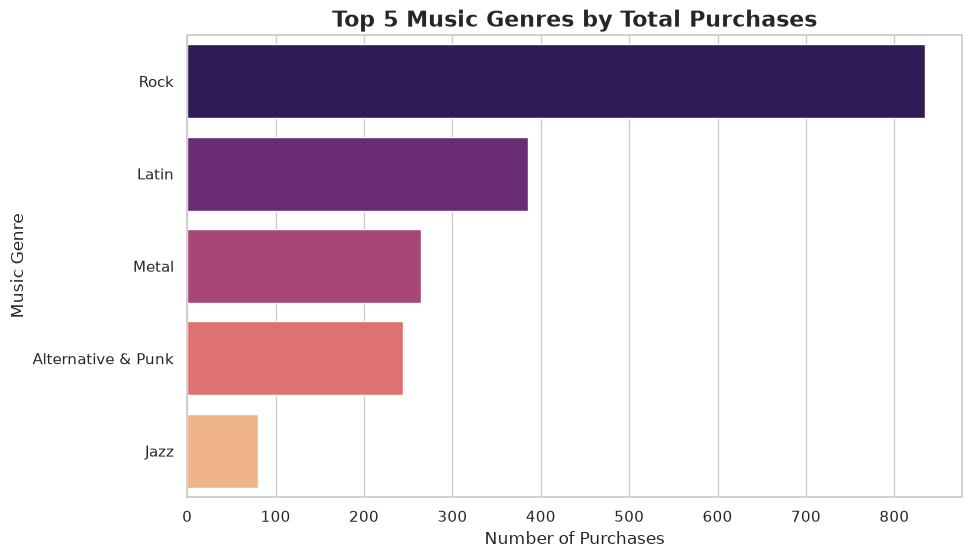

In [5]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional visual theme
sns.set_theme(style="whitegrid")

# Create a figure with a specific size
plt.figure(figsize=(10, 6))

# Create a horizontal bar chart showing total purchases per genre
# We use the 'top_genres' DataFrame we extracted using SQL
sns.barplot(
    data=top_genres, 
    x='TotalPurchases', 
    y='Genre', 
    hue='Genre', 
    palette='magma', 
    legend=False
)

# Add professional titles and labels for the client presentation
plt.title('Top 5 Music Genres by Total Purchases', fontsize=16, fontweight='bold')
plt.xlabel('Number of Purchases', fontsize=12)
plt.ylabel('Music Genre', fontsize=12)

# Display the plot
plt.show()

In [6]:
conn.close()